In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Loading Dataset


In [4]:
df = pd.read_excel(r"C://Users//Anuj Kumar//Desktop//Machine Learning//datasets//students.xlsx")

# Analyzing data

In [5]:
df.head()

,Student_ID,Name,Age,Attendance,Study_Hours,Extra_Hours,Marks
0,101,Amit,20,75,2,4,65
1,102,Sneha,21,76,3,6,67
2,103,John,22,77,4,8,69
3,104,Neha,20,78,5,10,71
4,105,Kiran,21,79,6,12,73


In [6]:
print(df.info())
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Student_ID   50 non-null     int64 
 1   Name         50 non-null     object
 2   Age          50 non-null     int64 
 3   Attendance   50 non-null     int64 
 4   Study_Hours  50 non-null     int64 
 5   Extra_Hours  50 non-null     int64 
 6   Marks        50 non-null     int64 
dtypes: int64(6), object(1)
memory usage: 2.9+ KB
None
       Student_ID        Age  Attendance  Study_Hours  Extra_Hours      Marks
count    50.00000  50.000000   50.000000    50.000000    50.000000  50.000000
mean    125.50000  20.980000   87.000000     4.000000     8.000000  80.520000
std      14.57738   0.820403    7.284314     1.428571     2.857143   9.465814
min     101.00000  20.000000   75.000000     2.000000     4.000000  65.000000
25%     113.25000  20.000000   81.000000     3.000000     6.000000  72.250000
50%   

In [7]:
df.isnull().sum()

Student_ID     0
Name           0
Age            0
Attendance     0
Study_Hours    0
Extra_Hours    0
Marks          0
dtype: int64

In [8]:
# Copying the dataset 
df1 = df.copy()

In [9]:
# We doesn't need name and id column for presiction so we will drop them

df1 = df1.drop(columns=["Student_ID","Name"],axis=1)

In [10]:
df1.columns

Index(['Age', 'Attendance', 'Study_Hours', 'Extra_Hours', 'Marks'], dtype='object')

In [11]:
df1.dtypes

Age            int64
Attendance     int64
Study_Hours    int64
Extra_Hours    int64
Marks          int64
dtype: object

In [12]:
df1.head()

,Age,Attendance,Study_Hours,Extra_Hours,Marks
0,20,75,2,4,65
1,21,76,3,6,67
2,22,77,4,8,69
3,20,78,5,10,71
4,21,79,6,12,73


In [13]:
# Settin input and output data

X = df1.drop(columns="Marks")
y = df1["Marks"]

In [23]:
print(X.head())
print(type(X))

   Age  Attendance  Study_Hours  Extra_Hours
0   20          75            2            4
1   21          76            3            6
2   22          77            4            8
3   20          78            5           10
4   21          79            6           12
<class 'pandas.core.frame.DataFrame'>


In [22]:
print(y.head())
print(type(y))

0    65
1    67
2    69
3    71
4    73
Name: Marks, dtype: int64
<class 'pandas.core.series.Series'>


# Visualization

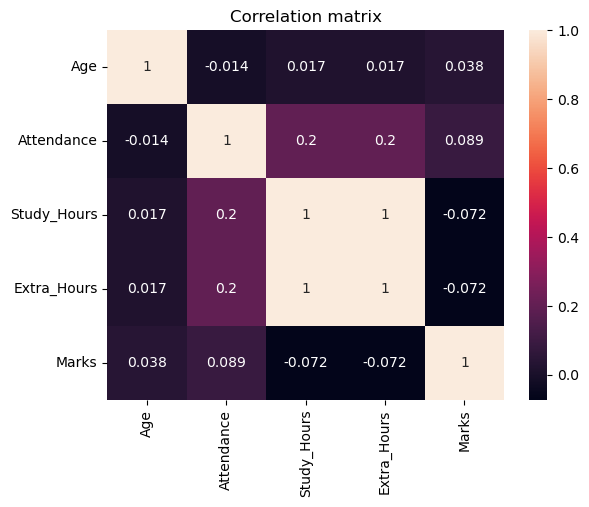

In [27]:
# Correlation

sns.heatmap(df1.corr(),annot=True)
plt.title("Correlation matrix")
plt.show()

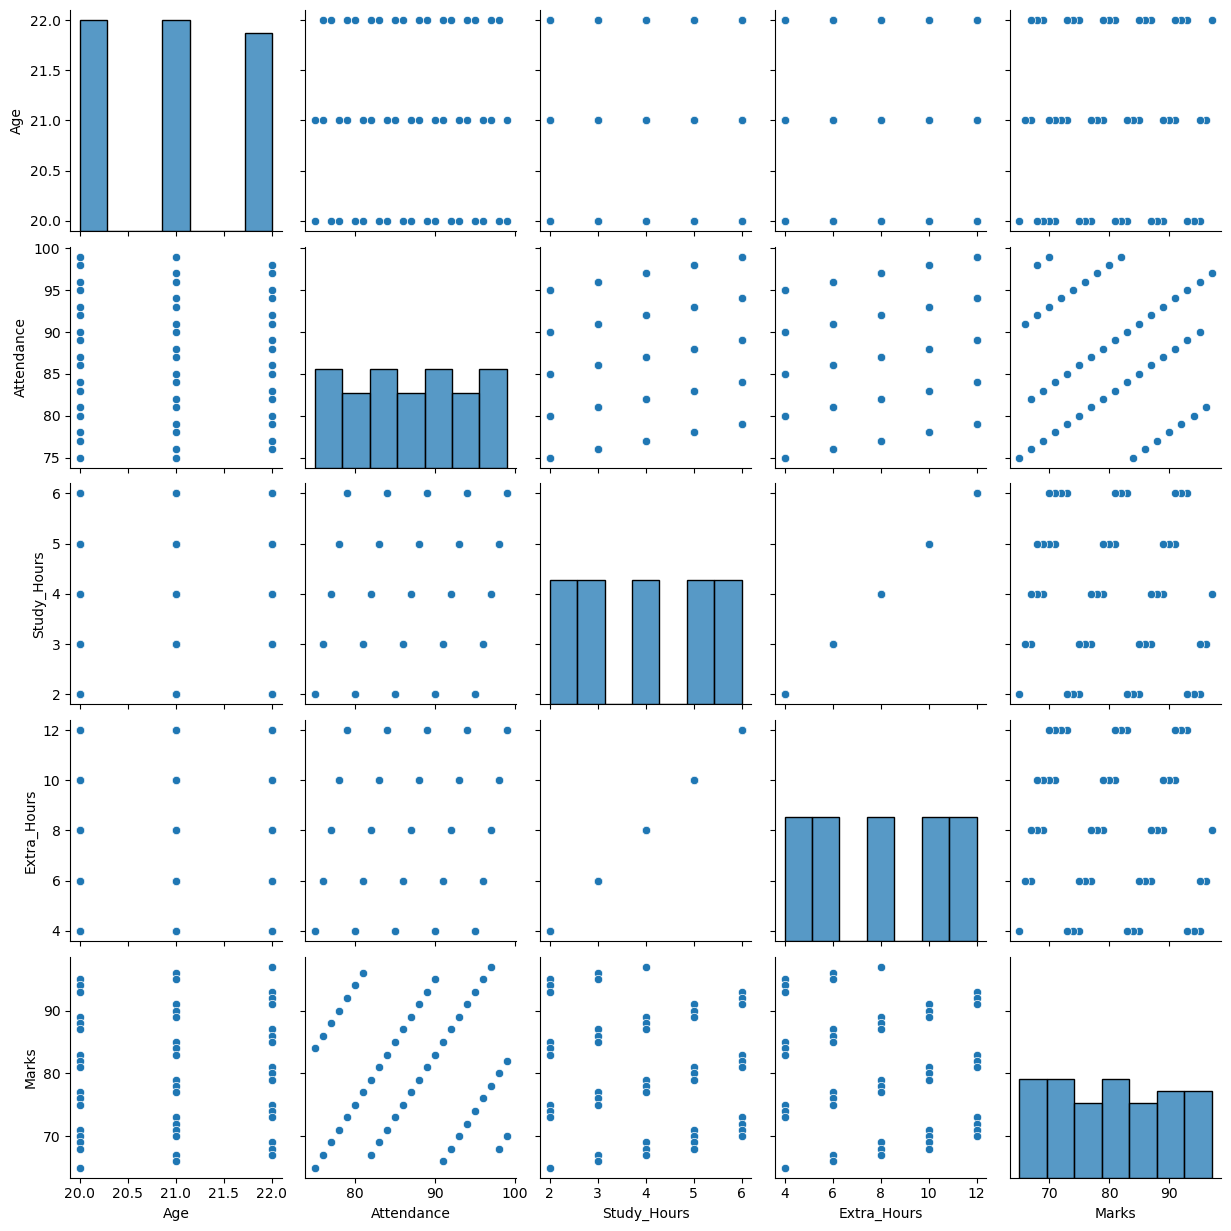

In [28]:
# Pair plot

sns.pairplot(df1)

# Splitting into train-test

In [29]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.25,random_state=42)

In [31]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(37, 4)
(13, 4)
(37,)
(13,)


In [43]:
# Model training

from sklearn.svm import SVR

model = SVR(kernel="rbf")

In [44]:
model.fit(X_train,y_train)
pred = model.predict(X_test)
print(pred)
print(y_test)

[79.84522349 79.87607491 79.66263573 79.90320677 79.89385502 79.99663402
 79.61902634 79.58545889 79.73223956 79.9554282  79.81040063 79.71627577
 79.81214187]
13    91
39    81
30    94
45    93
17    68
48    68
26    86
25    84
32    67
19    72
12    89
4     73
37    77
Name: Marks, dtype: int64


# Metrices

In [45]:
from sklearn.metrics import accuracy_score,r2_score

print(r2_score(y_test,pred))

-0.010784021030970425
